In [7]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import RobustScaler

In [ ]:
df = pd.read_csv("../data/german_credit_data.csv")
print(df.shape)

(284807, 31)
Class
0    0.998273
1    0.001727
Name: proportion, dtype: float64


(0.0, 500.0)

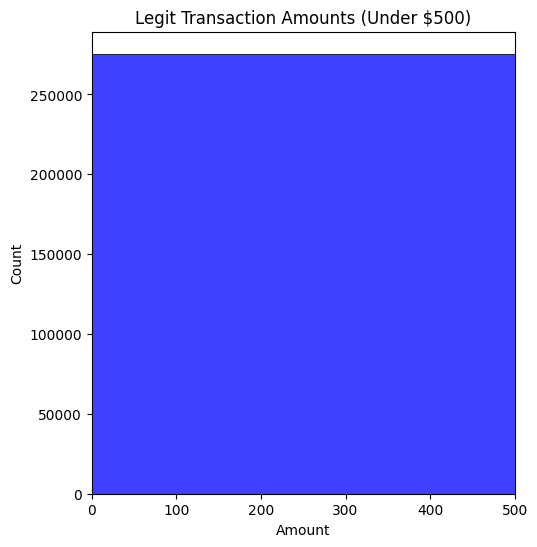

In [16]:
# 2. Visual Inspection: Amount vs Class
# Hypothesis: Are frauds usually big transactions or small ones?
plt.figure(figsize=(12,6))
plt.subplot(1,2,1)
sns.histplot(df[df['Class']==0]['Amount'], bins=50, color='blue', label='Legit')
plt.title("Legit Transaction Amounts (Under $500)")
plt.xlim(0, 500) # Zoom in


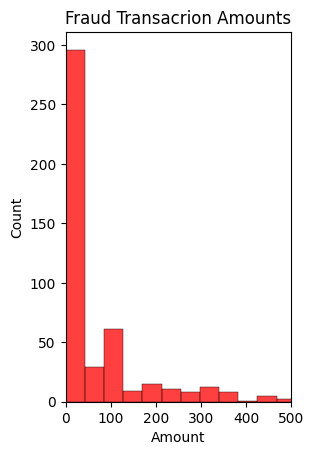

In [15]:
plt.subplot(1,2,2)
sns.histplot(df[df['Class'] == 1]['Amount'], color='red', label='Fraud', bins=50)
plt.title('Fraud Transacrion Amounts')
plt.xlim(0,500)
plt.show()


In [18]:
print('----- Stats ----- ')
print("Avg Legit Amount", df[df['Class'] == 0]['Amount'].mean())
print("Avg Fraud Amount", df[df['Class'] == 1]['Amount'].mean())

----- Stats ----- 
Avg Legit Amount 88.29102242231328
Avg Fraud Amount 122.21132113821139


In [20]:
# 3. Preprocessing (The Crucial Step)
# We drop 'Time' (it's just a counter) and Scale 'Amount'
new_df = df.copy()

# RobustScaler is better for outliers (Fraud = Outlier!)
scaler = RobustScaler()
new_df['Amount'] = scaler.fit_transform(new_df[['Amount']])

new_df.drop(['Time', 'Amount'], axis=1, inplace=True)

# Move 'Class' to the end for cleanliness
class_col = new_df.pop('Class')
new_df['Class'] = class_col

print("\n✅ Data Scaled and Ready.")
print(new_df.head())

# 4. Save for Modeling
new_df.to_csv('../data/creditcard_processed.csv', index=False)


✅ Data Scaled and Ready.
         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V20       V21       V22       V23  \
0  0.098698  0.363787  0.090794  ...  0.251412 -0.018307  0.277838 -0.110474   
1  0.085102 -0.255425 -0.166974  ... -0.069083 -0.225775 -0.638672  0.101288   
2  0.247676 -1.514654  0.207643  ...  0.524980  0.247998  0.771679  0.909412   
3  0.377436 -1.387024 -0.054952  ... -0.208038 -0.108300  0.005274 -0.190321   
4 -0.270533  0.817739  0.753074  ...  0.408542 -0.009431  0.798278 -0.137458   

        V24       V25       V26       V27 